# Model-free deconvolution with `pySPFM`

Multi-echo fMRI lets us estimate neuronal-related activity directly from the BOLD
signal *without* a task model, using Sparse Paradigm Free Mapping (SPFM).
[`pySPFM`](https://pyspfm.readthedocs.io) deconvolves the haemodynamic response from
the data and recovers a sparse **activity-inducing signal** — an estimate of *when*
each region becomes active — like the examples in the
[pySPFM documentation](https://pyspfm.readthedocs.io/en/stable/examples.html).

To keep the analysis fast and laptop-friendly we run the deconvolution
*parcel-wise*: averaging voxels within each region of the Schaefer atlas shrinks the
problem and boosts SNR, which makes the multi-echo fit well behaved.

## Load the multi-echo data

In [1]:
import json
import os
import warnings
from glob import glob

import nibabel as nb
import numpy as np
import matplotlib.pyplot as plt
from nilearn import plotting
from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.image import resample_to_img
from nilearn.maskers import NiftiLabelsMasker
from nilearn.signal import clean

warnings.filterwarnings("ignore")

data_path = os.path.abspath("../data")
func_dir = os.path.join(data_path, "ds006185/sub-24053/ses-1/func/")

data_files = sorted(
    glob(
        os.path.join(
            func_dir,
            "sub-24053_ses-1_task-rat_dir-PA_run-01_echo-*_part-mag_desc-preproc_bold.nii.gz",
        ),
    ),
)
mask_file = os.path.join(
    func_dir,
    "sub-24053_ses-1_task-rat_dir-PA_run-01_part-mag_desc-brain_mask.nii.gz",
)

if not data_files:
    raise FileNotFoundError(
        f"No echo files found under {func_dir}. Run the data download in "
        "`00_Download_Data` (datalad get of the task-rat_dir-PA echoes) first."
    )

# Read the echo times (converted to ms) and the repetition time (s) from the BIDS
# JSON sidecars, so the HRF is built with the correct acquisition timing.
echo_times = []
for f in data_files:
    with open(f.replace(".nii.gz", ".json"), "r") as fo:
        metadata = json.load(fo)
    echo_times.append(metadata["EchoTime"] * 1000)
tr = metadata["RepetitionTime"]

out_dir = os.path.join(data_path, "pySPFM")
os.makedirs(out_dir, exist_ok=True)

print(f"{len(data_files)} echoes | TE = {[round(t, 1) for t in echo_times]} ms | TR = {tr} s")

5 echoes | TE = [14.2, 38.9, 63.7, 88.4, 113.1] ms | TR = 1.761 s


## Parcellate, detrend and normalise

Each echo is averaged within Schaefer parcels (restricted to the brain mask), then
**detrended and band-pass filtered (0.01–0.1 Hz)**, and only then converted to
**percent signal change**. The order matters: we strip drift and out-of-band
fluctuations first, then express what remains as a fraction of the parcel's baseline.

- **Detrending and band-pass filtering** — scanner drift (below 0.01 Hz) and
  high-frequency noise (above 0.1 Hz, e.g. residual cardiac/respiratory and thermal
  noise) are not part of the haemodynamic response, so we keep only the 0.01–0.1 Hz
  band where the BOLD response lives.
- **Normalisation to percent signal change** — `pySPFM` expects normalised input;
  feeding raw signal intensities collapses the deconvolution to zero.

In [2]:
# Schaefer cortical parcellation. Averaging within ~400 parcels reduces the problem
# from ~218k voxels to a few hundred ROIs and improves SNR. Increase n_rois for a
# finer map at the cost of a longer fit.
# Download the atlas into the git-ignored ../data tree instead of the default
# ~/nilearn_data, so it does not clutter the user's home directory.
atlas = fetch_atlas_schaefer_2018(n_rois=400, data_dir=os.path.join(data_path, "nilearn"))

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    mask_img=mask_file,        # only average voxels inside the brain
    resampling_target="data",  # resample the atlas onto the fMRI's native grid
    standardize=False,
)
masker.fit(data_files[0])

masked_data = []
for f in data_files:
    echo_data = masker.transform(f)  # (n_timepoints, n_parcels)
    # Detrend and band-pass (0.01-0.1 Hz) first, then normalise: express the cleaned
    # signal as a fraction of the parcel's raw baseline mean (percent signal change).
    baseline = echo_data.mean(axis=0, keepdims=True)
    detrended = clean(
        echo_data, detrend=True, low_pass=0.1, high_pass=0.01, t_r=tr, standardize=False
    )
    with np.errstate(invalid="ignore", divide="ignore"):
        pc = detrended / baseline  # percent signal change
    masked_data.append(pc)

X = np.vstack(masked_data)  # (n_echoes * n_timepoints, n_parcels)
n_scans = X.shape[0] // len(data_files)

# Drop parcels that fall outside the field of view (empty/constant after masking).
valid = np.all(np.isfinite(X), axis=0) & (X.std(axis=0) > 0)
X = X[:, valid]

print(f"Input matrix: {X.shape}  ({len(data_files)} echoes x {n_scans} TRs, {X.shape[1]} parcels)")

[fetch_atlas_schaefer_2018] Dataset found in /Users/eurunuela/GitHub/multi-echo-data-analysis/data/nilearn/schaefer_2018


Input matrix: (1815, 358)  (5 echoes x 363 TRs, 358 parcels)


## Deconvolve: the effect of the model-selection criterion

`pySPFM` selects the amount of regularisation (i.e. how sparse the estimate is)
automatically from a *criterion*. We compare the two LARS-based criteria for the
multi-echo model:

- **`bic`** — a strong complexity penalty, so it keeps only the few most confident
  events (a very sparse estimate).
- **`aic`** — a lighter penalty, so it recovers activity-inducing events across most
  of the brain.

(The FISTA-based criteria such as `mad` are not numerically stable for the multi-echo
model on these data, so we stick to the LARS criteria.)

In [3]:
from pySPFM import SparseDeconvolution

models = {}
for criterion in ["bic", "aic"]:
    model = SparseDeconvolution(tr=tr, te=echo_times, criterion=criterion)
    model.fit(X)
    models[criterion] = model
    active = np.mean(np.any(model.coef_ != 0, axis=0)) * 100
    print(f"{criterion.upper()}: {active:.0f}% of parcels show activity")

# Guard against a silently degenerate fit (e.g. wrong scaling or TR).
assert np.any(models["aic"].coef_ != 0), "Deconvolution returned all zeros — check normalisation/TR."

np.save(os.path.join(out_dir, "out_activity_bic.npy"), models["bic"].coef_)
np.save(os.path.join(out_dir, "out_activity_aic.npy"), models["aic"].coef_)

dask configuration wasn't detected, if you are using a cluster please look at the jobqueue YAML example, modify it so it works in your cluster and add it to ~/.config/dask local configuration will be used.You can find a jobqueue YAML example in the pySPFM/jobqueue.yaml file.


BIC: 65% of parcels show activity


dask configuration wasn't detected, if you are using a cluster please look at the jobqueue YAML example, modify it so it works in your cluster and add it to ~/.config/dask local configuration will be used.You can find a jobqueue YAML example in the pySPFM/jobqueue.yaml file.


AIC: 96% of parcels show activity


## A single parcel: BIC vs. AIC

For one representative parcel: the band-pass-filtered BOLD (echo 2) with each model's fit, and
the activity-inducing signal recovered by each criterion. BIC keeps only a handful of
strong events; AIC recovers many more — the same trade-off illustrated in the pySPFM
documentation.

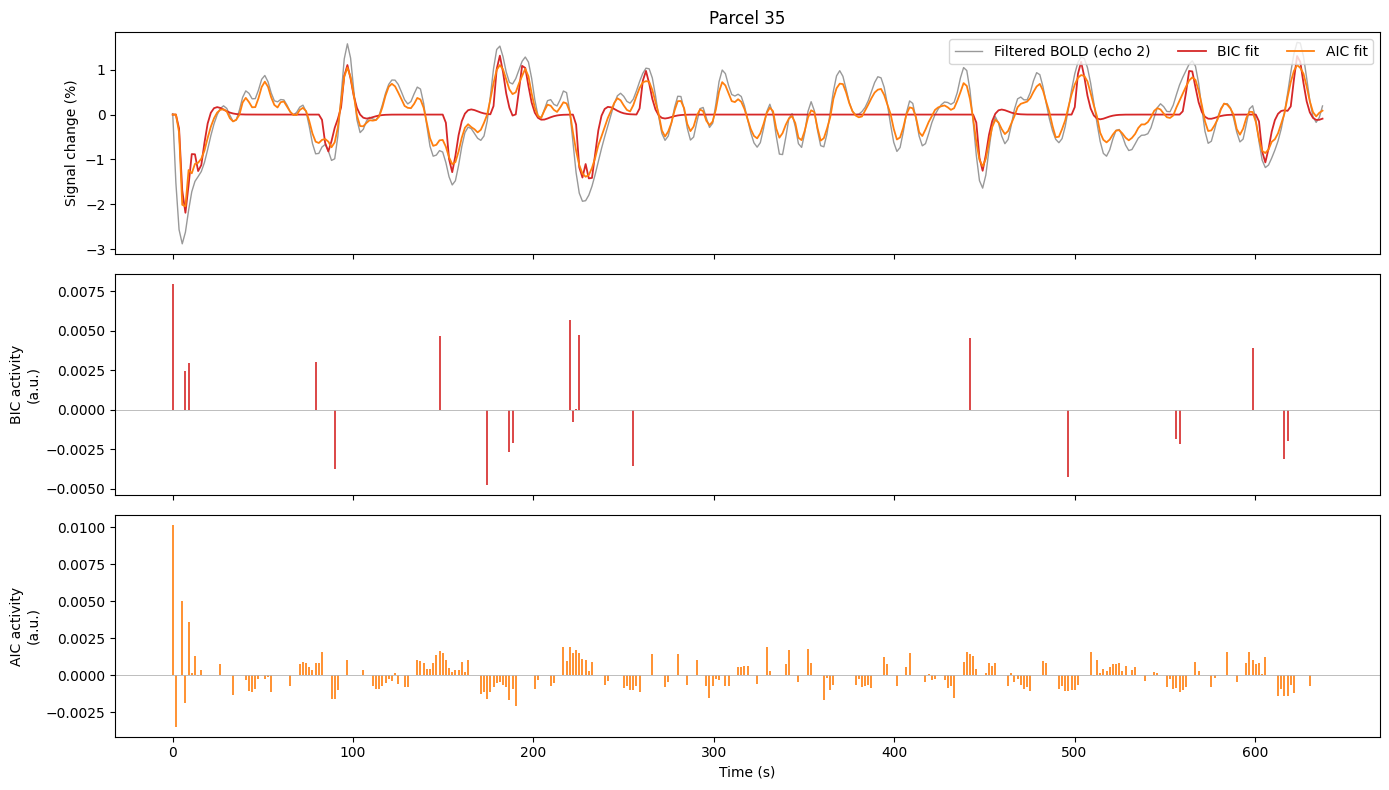

In [4]:
echo2 = masked_data[1][:, valid]                                   # filtered echo-2 % change
coef_bic, coef_aic = models["bic"].coef_, models["aic"].coef_
fit_bic = models["bic"].get_fitted_signal()[n_scans:2 * n_scans, :]
fit_aic = models["aic"].get_fitted_signal()[n_scans:2 * n_scans, :]

# Representative parcel: active in BIC, realistic amplitude, best AIC fit to the data.
amplitude = echo2.std(axis=0)
candidates = np.where(np.any(coef_bic != 0, axis=0) & (amplitude > 0.003) & (amplitude < 0.04))[0]
if candidates.size == 0:  # fall back to any active parcel
    candidates = np.where(np.any(coef_aic != 0, axis=0))[0]
corr = np.array([np.corrcoef(fit_aic[:, i], echo2[:, i])[0, 1] for i in candidates])
parcel = int(candidates[int(np.argmax(corr))])

t = np.arange(n_scans) * tr
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t, echo2[:, parcel] * 100, color="0.6", lw=1.0, label="Filtered BOLD (echo 2)")
axes[0].plot(t, fit_bic[:, parcel] * 100, color="tab:red", lw=1.3, label="BIC fit")
axes[0].plot(t, fit_aic[:, parcel] * 100, color="tab:orange", lw=1.3, label="AIC fit")
axes[0].set_ylabel("Signal change (%)")
axes[0].set_title(f"Parcel {parcel}")
axes[0].legend(loc="upper right", ncol=3)
axes[1].vlines(t, 0, coef_bic[:, parcel], color="tab:red", lw=1.2)
axes[1].axhline(0, color="0.7", lw=0.6)
axes[1].set_ylabel("BIC activity\n(a.u.)")
axes[2].vlines(t, 0, coef_aic[:, parcel], color="tab:orange", lw=1.2)
axes[2].axhline(0, color="0.7", lw=0.6)
axes[2].set_ylabel("AIC activity\n(a.u.)")
axes[2].set_xlabel("Time (s)")
fig.tight_layout()

## Whole-brain activity: BIC vs. AIC

The peak activity-inducing magnitude of each parcel, shown in MNI space. The
multi-echo data are in the subject's native space and are only affinely aligned to
MNI, so we map each parcel's value onto the original (MNI) Schaefer atlas:
`inverse_transform` would instead land on the native grid and would not line up with
the MNI template. Because the parcels were sampled in native space, the anatomical
labelling is approximate — good enough for a qualitative whole-brain map, not for
precise localisation. BIC highlights only a few strong regions, while AIC reveals
activity across most of the cortex.

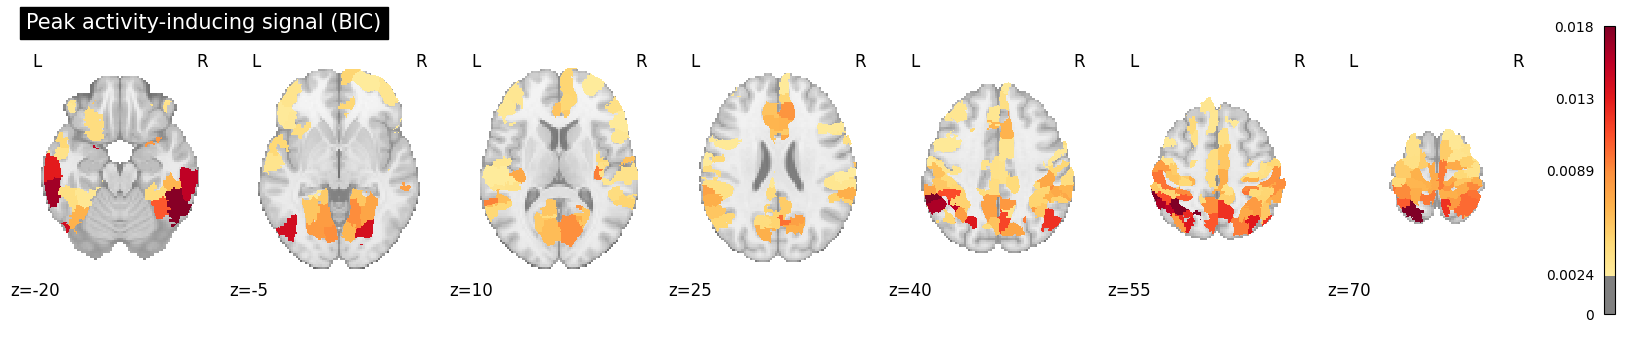

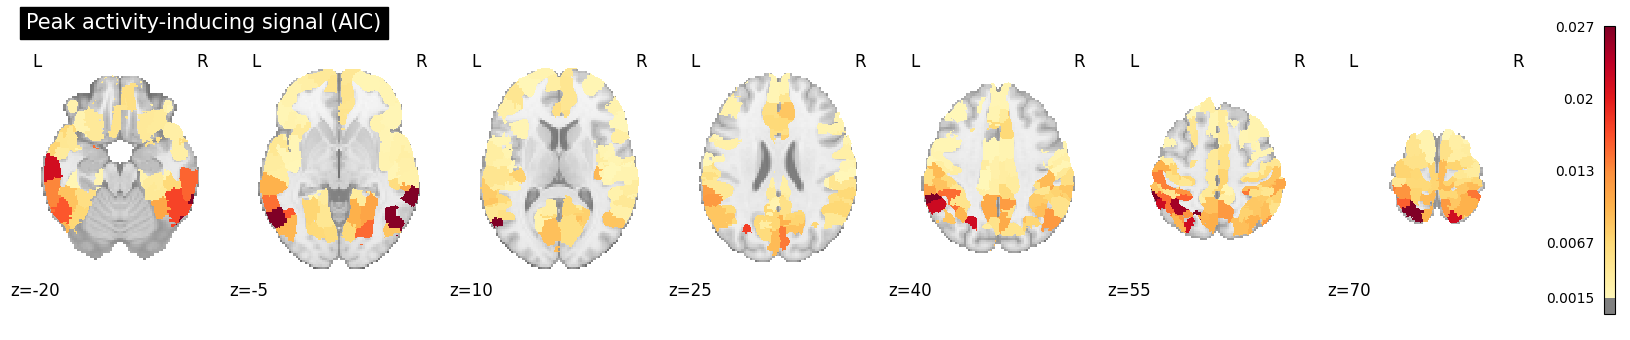

In [5]:
# The Schaefer atlas is defined in MNI space; the masker orders parcels by ascending
# label id and keeps those with voxels inside the brain mask. Recover that label
# order so each parcel's value can be painted back onto the MNI atlas.
atlas_img = nb.load(atlas.maps)
atlas_data = np.asarray(atlas_img.dataobj).astype(int)
atlas_on_data = resample_to_img(
    atlas_img, nb.load(mask_file), interpolation="nearest", force_resample=True, copy_header=True
).get_fdata().astype(int)
brain = nb.load(mask_file).get_fdata() > 0
labels = np.array(sorted(np.unique(atlas_on_data[brain & (atlas_on_data > 0)])))
assert labels.size == models["aic"].coef_.shape[1], "parcel/label count mismatch"

def peak_activity_map(coef):
    peak = np.abs(coef).max(axis=0)  # one value per parcel
    painted = np.zeros(atlas_data.shape)
    for value, label in zip(peak, labels):
        painted[atlas_data == label] = value
    return nb.Nifti1Image(painted, atlas_img.affine), peak

for criterion in ["bic", "aic"]:
    activity_img, peak = peak_activity_map(models[criterion].coef_)
    nonzero = peak[peak > 0]
    plotting.plot_stat_map(
        activity_img,
        display_mode="z",
        cut_coords=[-20, -5, 10, 25, 40, 55, 70],
        threshold=float(np.percentile(nonzero, 10)),
        vmax=float(np.percentile(nonzero, 99)),
        cmap="YlOrRd",
        symmetric_cbar=False,
        title=f"Peak activity-inducing signal ({criterion.upper()})",
        draw_cross=False,
    )

# Save the AIC whole-brain map (MNI space) for reference.
peak_activity_map(models["aic"].coef_)[0].to_filename(
    os.path.join(out_dir, "out_activity_max_aic.nii.gz")
)